In [19]:
fp = "/Users/calvinperumalla/datasets/medtronic/eeg/ACS_2024_database/P114/eeg/P114.txt"

In [20]:
from musereader import musereader
reader_ob = musereader(fp)

In [21]:
reader_ob.data

,ts,datetime,ch1,ch2,ch3,ch4
0,1.729537e+09,2024-10-21 11:56:51,41.589461,8.817514,1.394894,-171.872183
1,1.729537e+09,2024-10-21 11:56:51,29.408537,-20.357743,-6.144688,-179.888588
2,1.729537e+09,2024-10-21 11:56:51,20.146019,-20.570849,-7.759895,-73.867589
3,1.729537e+09,2024-10-21 11:56:51,24.859091,-6.441483,-4.237266,92.910401
4,1.729537e+09,2024-10-21 11:56:51,28.316372,-6.456925,-0.757705,214.598944
...,...,...,...,...,...,...
433987,1.729538e+09,2024-10-21 12:14:01,205.875035,191.697167,1619.067768,266.117904
433988,1.729538e+09,2024-10-21 12:14:01,364.643156,366.118064,2272.074701,400.351178
433989,1.729538e+09,2024-10-21 12:14:01,455.977859,479.601796,2568.870660,504.979625
433990,1.729538e+09,2024-10-21 12:14:01,505.412564,525.956507,1850.741386,575.642068


In [22]:
from museanalyzer import musemetrics
import json
annotations = json.load(open("/Users/calvinperumalla/git/inert_pipe/annotations_json/medtronic_hugo_data.json", 'r'))
findann = lambda x: [d for d in annotations if d['pid'] == x][0]['annotations']
#ann_101 = annotations[0]['annotations']
ann = findann('P114')
mm = musemetrics(ann, reader_ob, pid='P114')

In [23]:
mm.calculate_time_series()

/Users/calvinperumalla/git/eegflow/eeg_functions.py:86: UserWarning: Discarding nonzero nanoseconds in conversion.
  ).to_pydatetime()


here 2024-10-21 11:56:52.668126


In [24]:
#mm.metric_time_series['FAA_index'][0].shape
mm.metric_time_series['FAA_index'][1].shape

(514,)

In [25]:
mm.compute_metrics()

{'Fourth Arm Cutting': {'focus_index': 1.9357569163148889,
  'engagement_index': 1.5936522061153786,
  'FAA_index': -2.2642287753269477,
  'TLX': 0.18522047300913969},
 'Ring Tower Transfer': {'focus_index': 1.067457416927907,
  'engagement_index': 0.9838049047929243,
  'FAA_index': -2.2008730373465784,
  'TLX': 0.128240851109717},
 'calibration': {'focus_index': 1.947255893273995,
  'engagement_index': 0.9420931108029785,
  'FAA_index': -1.1956214356096113,
  'TLX': 1.8838097901926443},
 'full': {'focus_index': 1.6329432146692693,
  'engagement_index': 1.3694922597792891,
  'FAA_index': -2.2296673301166914,
  'TLX': 0.1672522834707746}}

In [26]:
'''
Building Intuition:
Focus index: how focused the participant is on the task
Engagement index: how engaged the participant is on the task
FAA: Enjoyment 
TLX: Task load index; a measure of cognitive load someone is experiencing during the task

Assumptions: The measures are all assuming that the participant is only paying attention to the task given

Channels -> power bands how do they compare

EEG channel -> Band pass filter (Isolate power bands) -> Compute band power within 2 second window to alpha-theta waves -

--> calculate the different metrics by division

What do the metrics mean
understand Channel location -> what are the measuring - neuroscience
understand alpha-theta wave infomration -> what are they measuring in the brain.
artefacts: EMG, eye blinks, movement, ; radio noise - BT, WiFi? -powerline noise


Analysis:
Differences with High scorers and low scorers (Normal distribution)
Scores vs metrics (correlation test)

Click2Scrub

Which task had the highest cognitive workload/focus/engagement etc.,
eeg metrics vs task
eeg metrics vs task

'''

'\nBuilding Intuition:\nFocus index: how focused the participant is on the task\nEngagement index: how engaged the participant is on the task\nFAA: Enjoyment \nTLX: Task load index; a measure of cognitive load someone is experiencing during the task\n\nAssumptions: The measures are all assuming that the participant is only paying attention to the task given\n\nChannels -> power bands how do they compare\n\nEEG channel -> Band pass filter (Isolate power bands) -> Compute band power within 2 second window to alpha-theta waves -\n\n--> calculate the different metrics by division\n\nWhat do the metrics mean\nunderstand Channel location -> what are the measuring - neuroscience\nunderstand alpha-theta wave infomration -> what are they measuring in the brain.\nartefacts: EMG, eye blinks, movement, ; radio noise - BT, WiFi? -powerline noise\n\n\nAnalysis:\nDifferences with High scorers and low scorers (Normal distribution)\nScores vs metrics (correlation test)\n\nClick2Scrub\n\nWhich task had 

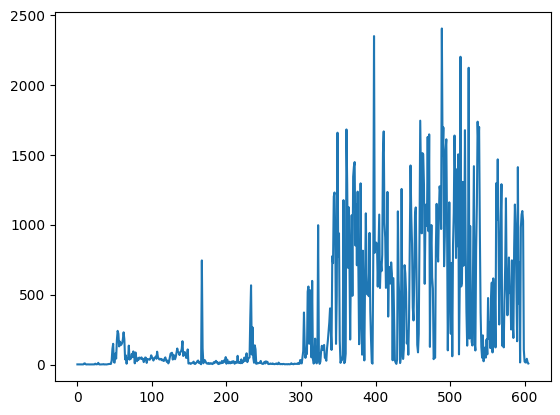

In [ ]:
plt.plot(p177_focus)

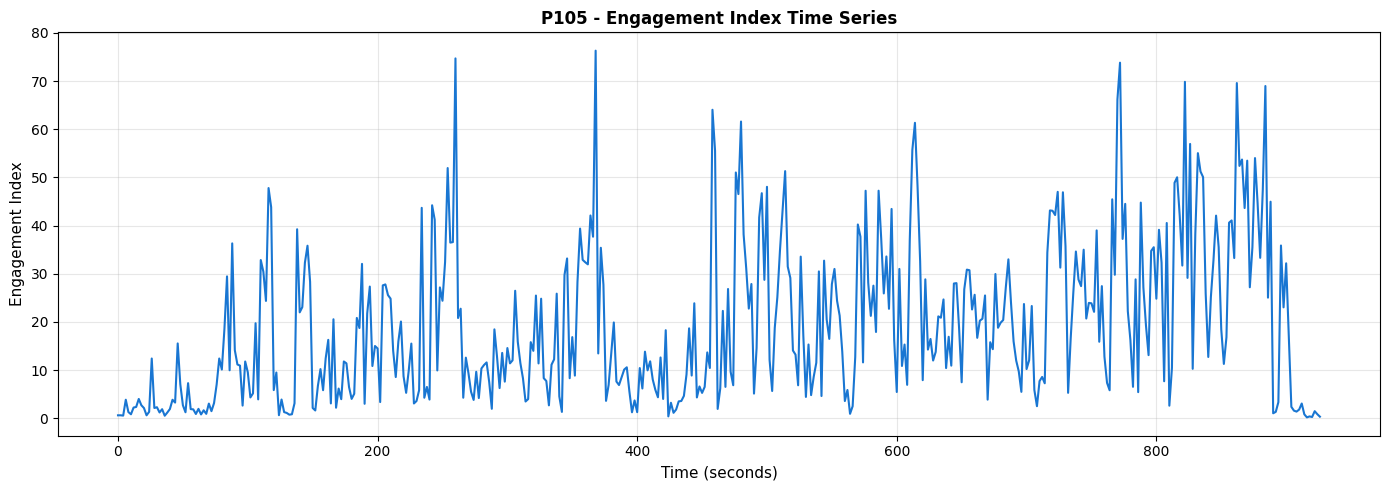

P105 Engagement Index Statistics:
  Mean: 19.2269
  Min: 0.1976
  Max: 76.3157
  Duration: 926 seconds


In [50]:
import json
import matplotlib.pyplot as plt
from datetime import datetime

# ===== CONFIGURATION =====
PID = 'P105'  # Change this to plot a different surgeon
# ========================

# Load metrics data
with open('eeg_metrics_results.json') as f:
    metrics_data = json.load(f)

# Find the specified surgeon
surgeon_data = None
for item in metrics_data:
    if item['sid'] == PID:
        surgeon_data = item
        break

if surgeon_data:
    # Get time series data
    time_series = surgeon_data['time_series']
    timestamps = time_series['time']
    engagement_index = time_series['engagement_index']
    
    # Convert timestamps to seconds elapsed
    start_time = datetime.fromisoformat(timestamps[0])
    seconds = [(datetime.fromisoformat(ts) - start_time).total_seconds() for ts in timestamps]
    
    # Plot
    plt.figure(figsize=(14, 5))
    plt.plot(seconds, engagement_index, linewidth=1.5, color='#1976D2')
    plt.xlabel('Time (seconds)', fontsize=11)
    plt.ylabel('Engagement Index', fontsize=11)
    plt.title(f'{PID} - Engagement Index Time Series', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"{PID} Engagement Index Statistics:")
    print(f"  Mean: {sum(engagement_index)/len(engagement_index):.4f}")
    print(f"  Min: {min(engagement_index):.4f}")
    print(f"  Max: {max(engagement_index):.4f}")
    print(f"  Duration: {seconds[-1]:.0f} seconds")
else:
    print(f"{PID} not found in metrics data")

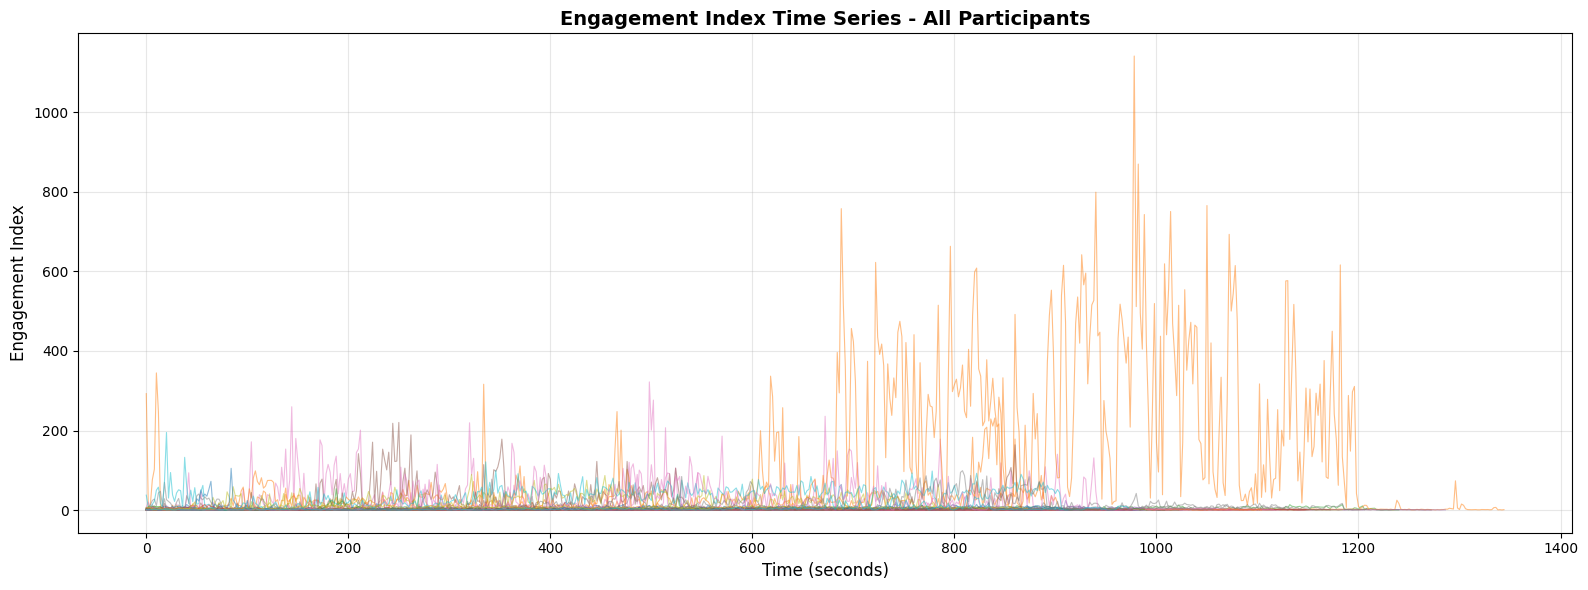


Engagement Index Summary Across All Participants:
  Mean of means: 8.5028
  Min of means: 0.4242
  Max of means: 131.9752
  Std of means: 19.9235
  Median duration: 980 seconds


In [40]:
import json
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# Load metrics data
with open('eeg_metrics_results.json') as f:
    metrics_data = json.load(f)

# Create figure
plt.figure(figsize=(16, 6))

# Plot engagement index for all surgeons
for item in metrics_data:
    sid = item['sid']
    time_series = item['time_series']
    timestamps = time_series['time']
    engagement_index = time_series['engagement_index']
    
    # Convert timestamps to seconds elapsed
    start_time = datetime.fromisoformat(timestamps[0])
    seconds = [(datetime.fromisoformat(ts) - start_time).total_seconds() for ts in timestamps]
    
    # Plot with transparency for visibility
    plt.plot(seconds, engagement_index, linewidth=0.8, alpha=0.5, label=sid)

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Engagement Index', fontsize=12)
plt.title('Engagement Index Time Series - All Participants', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
engagement_means = []
for item in metrics_data:
    time_series = item['time_series']
    engagement_index = time_series['engagement_index']
    engagement_means.append(np.nanmean(engagement_index))

engagement_means = np.array(engagement_means)
print("\nEngagement Index Summary Across All Participants:")
print(f"  Mean of means: {np.nanmean(engagement_means):.4f}")
print(f"  Min of means: {np.nanmin(engagement_means):.4f}")
print(f"  Max of means: {np.nanmax(engagement_means):.4f}")
print(f"  Std of means: {np.nanstd(engagement_means):.4f}")
print(f"  Median duration: {np.median([len(item['time_series']['time']) * 2 for item in metrics_data]):.0f} seconds")

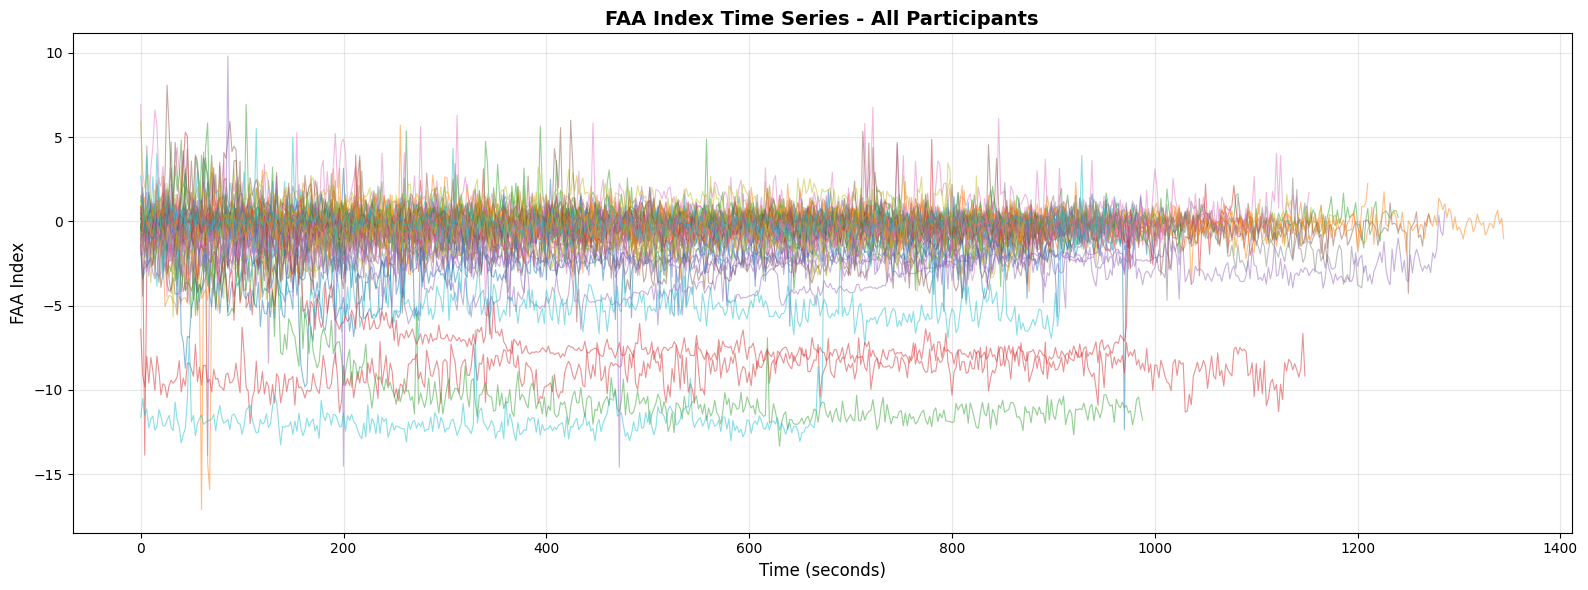


FAA Index Summary Across All Participants:
  Mean of means: -1.3521
  Min of means: -11.8741
  Max of means: 1.2401
  Std of means: 2.5753
  Median duration: 980 seconds


In [44]:
import json
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# Load metrics data
with open('eeg_metrics_results.json') as f:
    metrics_data = json.load(f)

# Create figure
plt.figure(figsize=(16, 6))

# Plot FAA index for all surgeons
for item in metrics_data:
    sid = item['sid']
    time_series = item['time_series']
    timestamps = time_series['time']
    faa_index = time_series['FAA_index']
    
    # Convert timestamps to seconds elapsed
    start_time = datetime.fromisoformat(timestamps[0])
    seconds = [(datetime.fromisoformat(ts) - start_time).total_seconds() for ts in timestamps]
    
    # Plot with transparency for visibility
    plt.plot(seconds, faa_index, linewidth=0.8, alpha=0.5, label=sid)

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('FAA Index', fontsize=12)
plt.title('FAA Index Time Series - All Participants', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
faa_means = []
for item in metrics_data:
    time_series = item['time_series']
    faa_index = time_series['FAA_index']
    faa_means.append(np.nanmean(faa_index))

faa_means = np.array(faa_means)
print("\nFAA Index Summary Across All Participants:")
print(f"  Mean of means: {np.nanmean(faa_means):.4f}")
print(f"  Min of means: {np.nanmin(faa_means):.4f}")
print(f"  Max of means: {np.nanmax(faa_means):.4f}")
print(f"  Std of means: {np.nanstd(faa_means):.4f}")
print(f"  Median duration: {np.median([len(item['time_series']['time']) * 2 for item in metrics_data]):.0f} seconds")

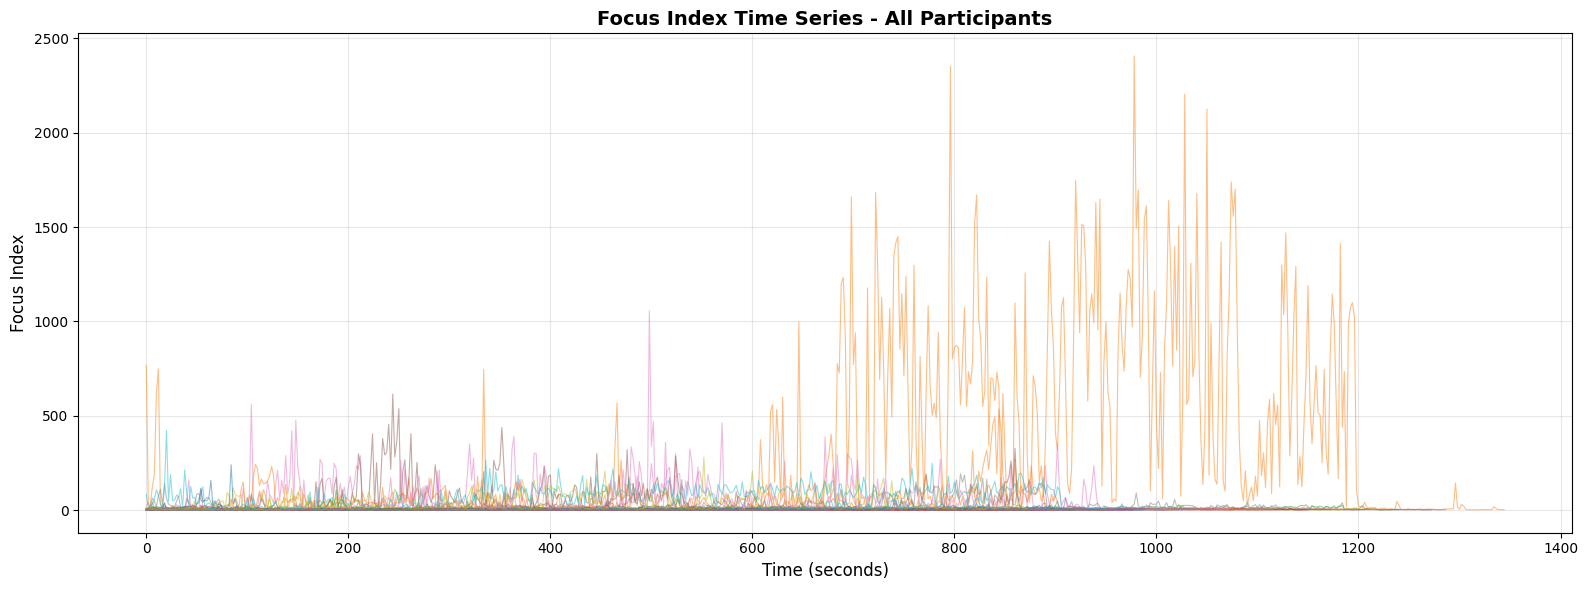


Focus Index Summary Across All Participants:
  Mean of means: 18.9405
  Min of means: 0.8639
  Max of means: 335.4195
  Std of means: 48.9419
  Median duration: 980 seconds


In [43]:
import json
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# Load metrics data
with open('eeg_metrics_results.json') as f:
    metrics_data = json.load(f)

# Create figure
plt.figure(figsize=(16, 6))

# Plot focus index for all surgeons
for item in metrics_data:
    sid = item['sid']
    time_series = item['time_series']
    timestamps = time_series['time']
    focus_index = time_series['focus_index']
    
    # Convert timestamps to seconds elapsed
    start_time = datetime.fromisoformat(timestamps[0])
    seconds = [(datetime.fromisoformat(ts) - start_time).total_seconds() for ts in timestamps]
    
    # Plot with transparency for visibility
    plt.plot(seconds, focus_index, linewidth=0.8, alpha=0.5, label=sid)

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Focus Index', fontsize=12)
plt.title('Focus Index Time Series - All Participants', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
focus_means = []
for item in metrics_data:
    time_series = item['time_series']
    focus_index = time_series['focus_index']
    focus_means.append(np.nanmean(focus_index))

focus_means = np.array(focus_means)
print("\nFocus Index Summary Across All Participants:")
print(f"  Mean of means: {np.nanmean(focus_means):.4f}")
print(f"  Min of means: {np.nanmin(focus_means):.4f}")
print(f"  Max of means: {np.nanmax(focus_means):.4f}")
print(f"  Std of means: {np.nanstd(focus_means):.4f}")
print(f"  Median duration: {np.median([len(item['time_series']['time']) * 2 for item in metrics_data]):.0f} seconds")

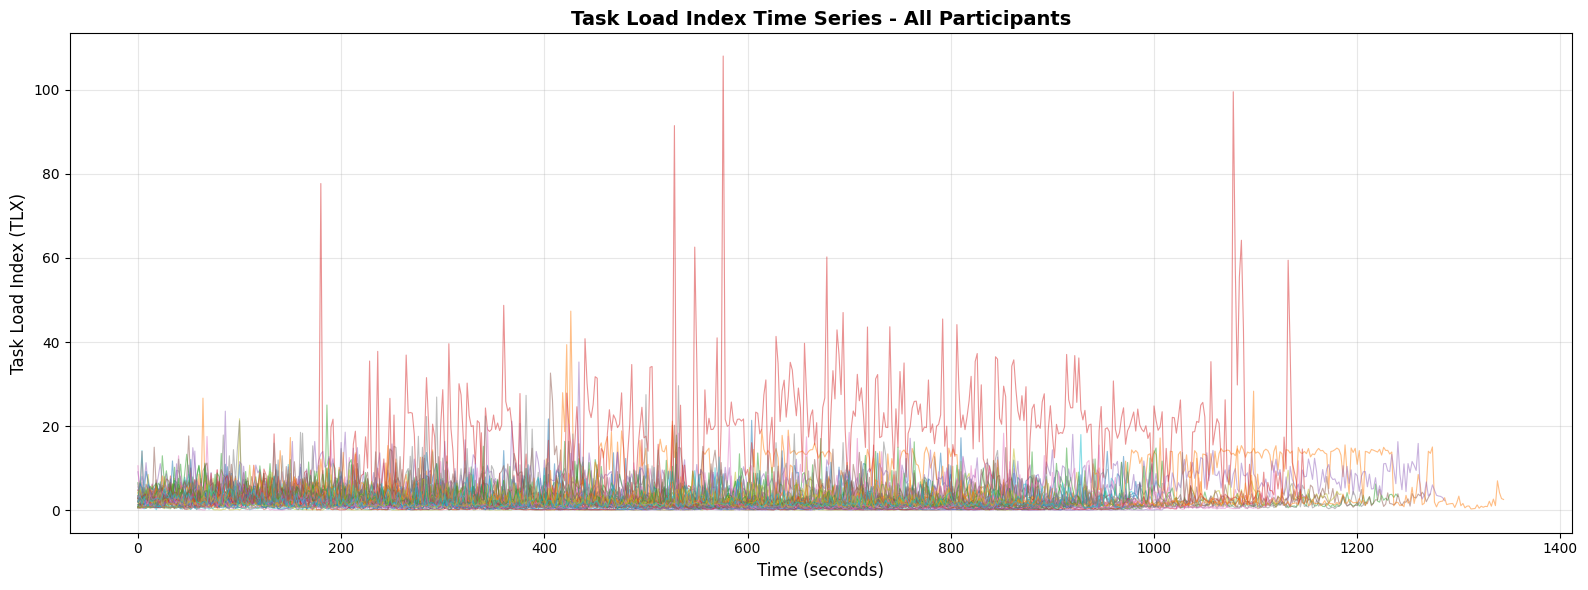


Task Load Index (TLX) Summary Across All Participants:
  Mean of means: 2.6417
  Min of means: 0.3314
  Max of means: 15.9055
  Std of means: 2.3297
  Median duration: 980 seconds


In [46]:
import json
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# Load metrics data
with open('eeg_metrics_results.json') as f:
    metrics_data = json.load(f)

# Create figure
plt.figure(figsize=(16, 6))

# Plot TLX for all surgeons
for item in metrics_data:
    sid = item['sid']
    time_series = item['time_series']
    timestamps = time_series['time']
    tlx = time_series['TLX']
    
    # Convert timestamps to seconds elapsed
    start_time = datetime.fromisoformat(timestamps[0])
    seconds = [(datetime.fromisoformat(ts) - start_time).total_seconds() for ts in timestamps]
    
    # Plot with transparency for visibility
    plt.plot(seconds, tlx, linewidth=0.8, alpha=0.5, label=sid)

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Task Load Index (TLX)', fontsize=12)
plt.title('Task Load Index Time Series - All Participants', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
tlx_means = []
for item in metrics_data:
    time_series = item['time_series']
    tlx = time_series['TLX']
    tlx_means.append(np.nanmean(tlx))

tlx_means = np.array(tlx_means)
print("\nTask Load Index (TLX) Summary Across All Participants:")
print(f"  Mean of means: {np.nanmean(tlx_means):.4f}")
print(f"  Min of means: {np.nanmin(tlx_means):.4f}")
print(f"  Max of means: {np.nanmax(tlx_means):.4f}")
print(f"  Std of means: {np.nanstd(tlx_means):.4f}")
print(f"  Median duration: {np.median([len(item['time_series']['time']) * 2 for item in metrics_data]):.0f} seconds")

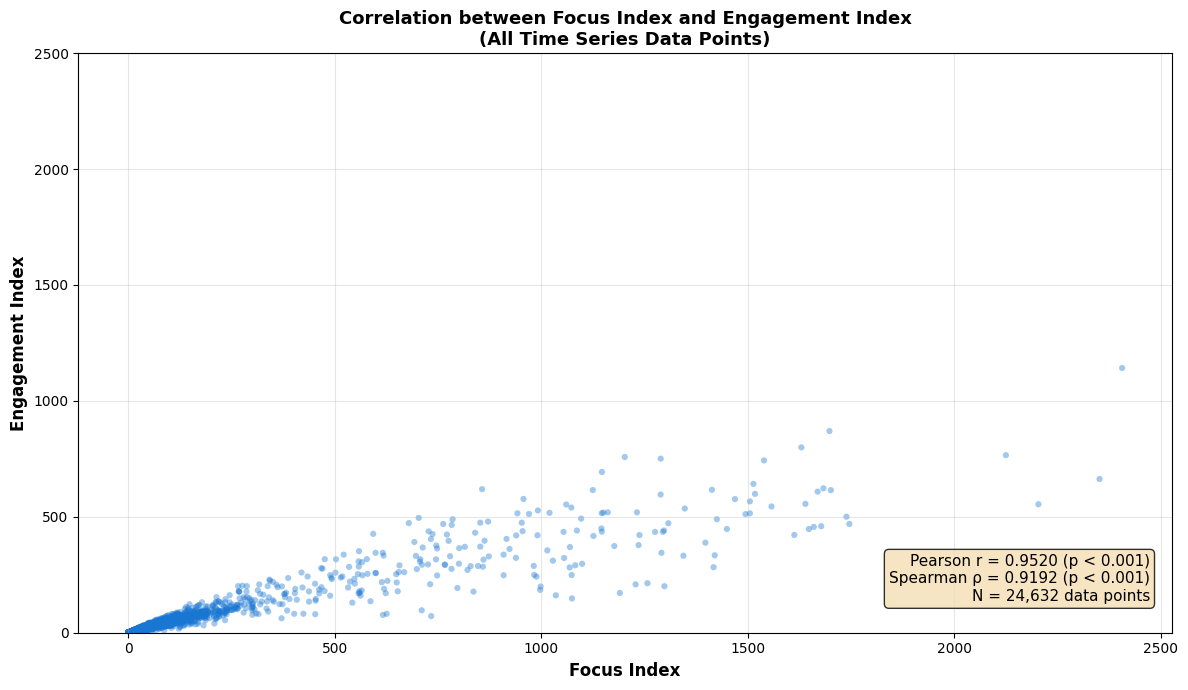

Focus vs Engagement Index Correlation Analysis
Total data points: 24,632

Pearson Correlation: 0.952042
  P-value: 0.00e+00

Spearman Correlation: 0.919248
  P-value: 0.00e+00

Focus Index - Min: 0.0614, Max: 2406.1826, Mean: 18.7579
Engagement Index - Min: 0.0317, Max: 1141.8263, Mean: 8.2199


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Load metrics data
with open('eeg_metrics_results.json') as f:
    metrics_data = json.load(f)

# Extract all focus and engagement values across all surgeons
all_focus = [] 
all_engagement = []

for item in metrics_data:
    time_series = item['time_series']
    focus_index = time_series['focus_index']
    engagement_index = time_series['engagement_index']
    
    # Add all data points
    all_focus.extend(focus_index)
    all_engagement.extend(engagement_index)

all_focus = np.array(all_focus)
all_engagement = np.array(all_engagement)

# Calculate correlations
pearson_corr, pearson_pval = pearsonr(all_focus, all_engagement)
spearman_corr, spearman_pval = spearmanr(all_focus, all_engagement)

# Create scatter plot
plt.figure(figsize=(12, 7))
plt.scatter(all_focus, all_engagement, alpha=0.4, s=20, color='#1976D2', edgecolors='none')

plt.xlabel('Focus Index', fontsize=12, fontweight='bold')
plt.ylim(0, 2500)
plt.ylabel('Engagement Index', fontsize=12, fontweight='bold')
plt.title('Correlation between Focus Index and Engagement Index\n(All Time Series Data Points)', 
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Add text box with correlation info
textstr = f'Pearson r = {pearson_corr:.4f} (p < 0.001)\nSpearman ρ = {spearman_corr:.4f} (p < 0.001)\nN = {len(all_focus):,} data points'
plt.text(0.98, 0.05, textstr, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.show()

print(f"Focus vs Engagement Index Correlation Analysis")
print(f"=" * 50)
print(f"Total data points: {len(all_focus):,}")
print(f"\nPearson Correlation: {pearson_corr:.6f}")
print(f"  P-value: {pearson_pval:.2e}")
print(f"\nSpearman Correlation: {spearman_corr:.6f}")
print(f"  P-value: {spearman_pval:.2e}")
print(f"\nFocus Index - Min: {np.min(all_focus):.4f}, Max: {np.max(all_focus):.4f}, Mean: {np.mean(all_focus):.4f}")
print(f"Engagement Index - Min: {np.min(all_engagement):.4f}, Max: {np.max(all_engagement):.4f}, Mean: {np.mean(all_engagement):.4f}")

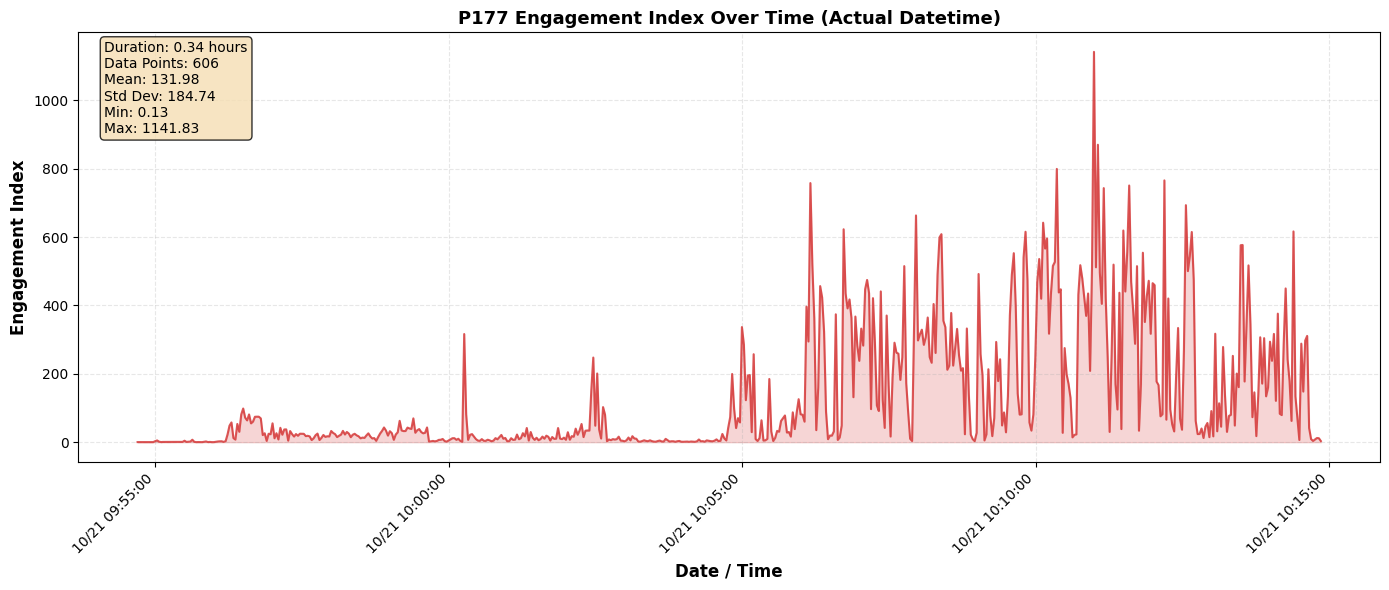

P177 Engagement Index Analysis
Start Time: 10/21/2024 09:54:41
End Time: 10/21/2024 10:14:51
Total data points: 606
Total duration: 0.34 hours (20.2 minutes)

Engagement Index Statistics:
  Mean: 131.9752
  Std Dev: 184.7403
  Min: 0.1345
  Max: 1141.8263
  Median: 32.2997


In [58]:
# Plot P177 Engagement Index with Actual Time
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime

# Load metrics data (or use existing metrics_data if already loaded)
try:
    # Use the metrics_data that was already loaded in a previous cell
    if 'metrics_data' not in locals():
        with open('metrics/eeg_metrics_results.json') as f:
            metrics_data = json.load(f)
except FileNotFoundError:
    print("Error: Could not find metrics file. Using existing metrics_data variable.")

# Find P177 data - HUGO metrics use 'sid' key, not 'pid'
p177_data = None
for item in metrics_data:
    if item.get('sid') == 'P177' or item.get('pid') == 'P177':
        p177_data = item
        break

if p177_data:
    # Extract engagement index time series
    engagement_index = p177_data['time_series']['engagement_index']
    timestamps_iso = p177_data['time_series']['time']
    
    # Convert ISO timestamps to datetime objects
    timestamps = [datetime.fromisoformat(ts) for ts in timestamps_iso]
    
    num_points = len(engagement_index)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot engagement index with actual datetime
    ax.plot(timestamps, engagement_index, linewidth=1.5, color='#D32F2F', alpha=0.8)
    ax.fill_between(timestamps, engagement_index, alpha=0.2, color='#D32F2F')
    
    # Format x-axis to show mm dd hh:mm:ss
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M:%S'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')
    
    # Formatting
    ax.set_xlabel('Date / Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Engagement Index', fontsize=12, fontweight='bold')
    ax.set_title('P177 Engagement Index Over Time (Actual Datetime)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add statistics box
    total_duration = (timestamps[-1] - timestamps[0]).total_seconds()
    stats_text = f'Duration: {total_duration/3600:.2f} hours\nData Points: {num_points}\nMean: {np.nanmean(engagement_index):.2f}\nStd Dev: {np.nanstd(engagement_index):.2f}\nMin: {np.nanmin(engagement_index):.2f}\nMax: {np.nanmax(engagement_index):.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print(f"P177 Engagement Index Analysis")
    print(f"=" * 50)
    print(f"Start Time: {timestamps[0].strftime('%m/%d/%Y %H:%M:%S')}")
    print(f"End Time: {timestamps[-1].strftime('%m/%d/%Y %H:%M:%S')}")
    print(f"Total data points: {num_points}")
    print(f"Total duration: {total_duration/3600:.2f} hours ({total_duration/60:.1f} minutes)")
    print(f"\nEngagement Index Statistics:")
    print(f"  Mean: {np.nanmean(engagement_index):.4f}")
    print(f"  Std Dev: {np.nanstd(engagement_index):.4f}")
    print(f"  Min: {np.nanmin(engagement_index):.4f}")
    print(f"  Max: {np.nanmax(engagement_index):.4f}")
    print(f"  Median: {np.nanmedian(engagement_index):.4f}")
else:
    print("P177 not found in metrics data")